# **Visión por computadora I**
## TRABAJO PRACTICO 1
### INTEGRANTES:

* Diego Vazquez
* Hernando Scheidl
* Martin Lacheski
* Nicolas Lastra

In [9]:
%matplotlib inline  
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## Parte 1 (imágenes en **/Material/white_patch**):
1. Implementar el algoritmo `White Patch` para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

In [10]:
def algoritmo_white_patch(imagen_entrada, percentil=100):

    # Se verifica si el parámetro es una imagen o al menos el tipo de dato.
    if not isinstance(imagen_entrada, np.ndarray):
        raise TypeError("No hay imagen para procesar")
    if imagen_entrada.ndim != 3 or imagen_entrada.shape[2] != 3:
        raise ValueError(f"Se esperaba imagen color (H, W, 3), llegó {imagen_entrada.shape}")
    if not 0 < percentil <= 100:
        raise ValueError(f"El percentil debe estar entre 0 y 100, llegó {percentil}")

    # Creamos una copia de la imagen con valores flotantes.
    imagen_float = imagen_entrada.astype(np.float64)
    referencias = np.zeros(3)

    # Recorremos los 3 canales.
    for canal in range(3):
        referencias[canal] = np.percentile(imagen_float[:, :, canal], percentil)
        if referencias[canal] > 0:
            imagen_float[:, :, canal] *= 255.0 / referencias[canal]

    # El clip ahora es necesario: los píxeles por encima del percentil superan 255.
    imagen_salida = np.clip(imagen_float, 0, 255).astype(np.uint8)
    return imagen_salida, referencias

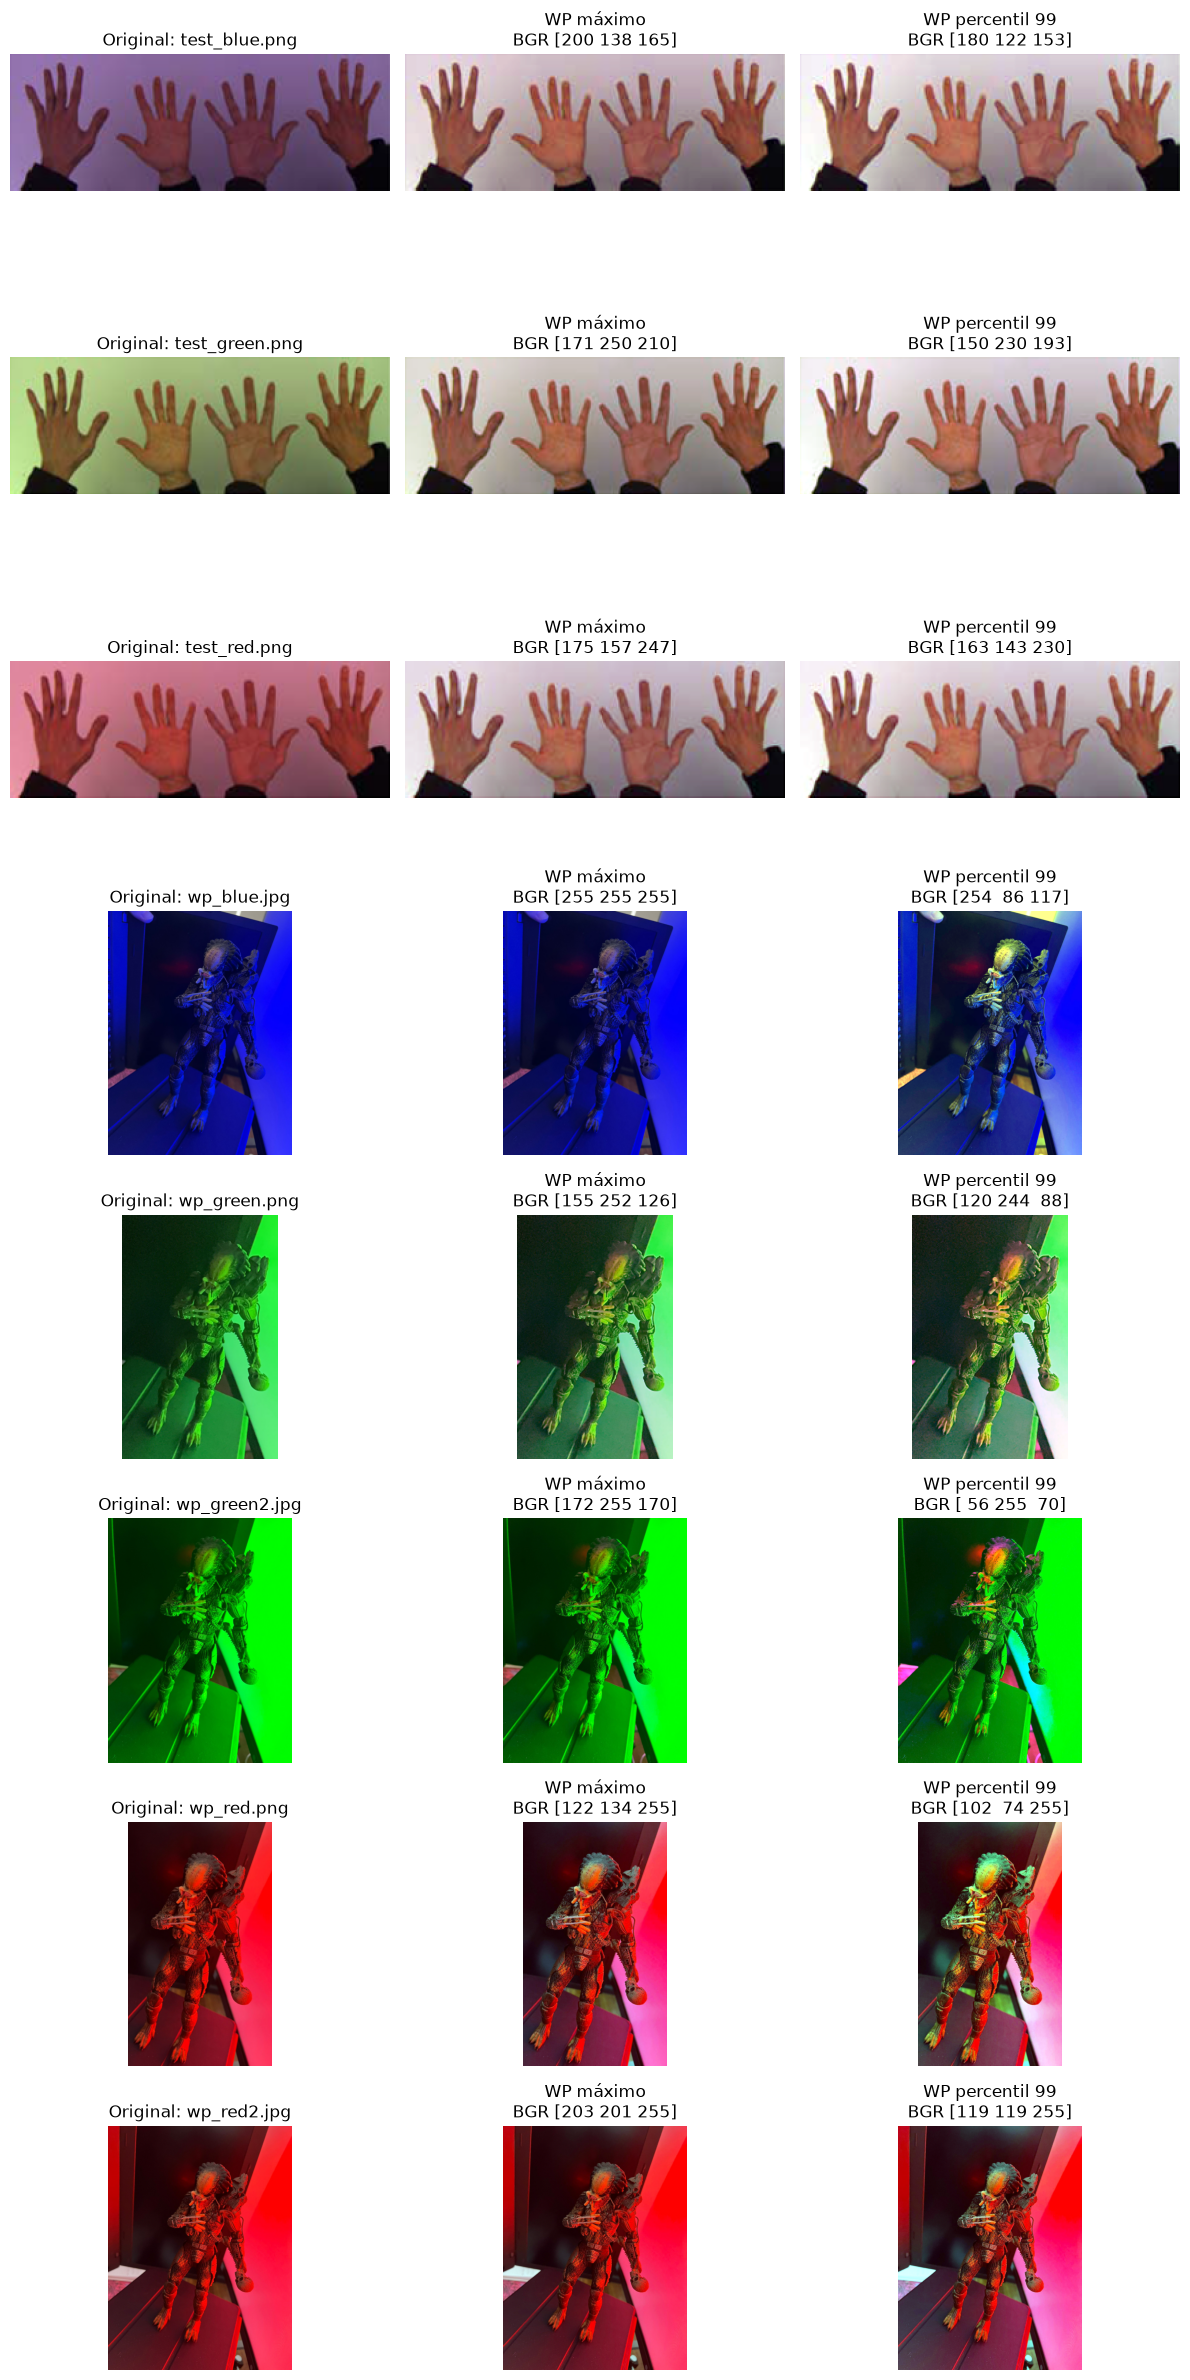

In [11]:
# Detectamos la ruta de cada imagen dentro de la carpeta white_patch y filtramos por extensión.
carpeta_white_patch = Path("Material/white_patch")
extensiones = {".jpg", ".jpeg", ".png", ".bmp"}
rutas = sorted(p for p in carpeta_white_patch.iterdir() if p.suffix.lower() in extensiones)

# Una fila por imagen y 3 columnas: original, White Patch (máximo) y White Patch (percentil 99).
fig, axes = plt.subplots(len(rutas), 3, figsize=(12, 3 * len(rutas)), squeeze=False)

# Procesamos cada imagen mostrando las referencias de los 3 canales.
for i, ruta in enumerate(rutas):
    img = cv.imread(str(ruta))
    salida_max, maximos_p100 = algoritmo_white_patch(img)
    salida_p99, maximos_p199 = algoritmo_white_patch(img, percentil=99)

    axes[i, 0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original: {ruta.name}")

    axes[i, 1].imshow(cv.cvtColor(salida_max, cv.COLOR_BGR2RGB))
    axes[i, 1].set_title(f"WP máximo\nBGR {maximos_p100.astype(int)}")

    axes[i, 2].imshow(cv.cvtColor(salida_p99, cv.COLOR_BGR2RGB))
    axes[i, 2].set_title(f"WP percentil 99\nBGR {maximos_p199.astype(int)}")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

| Imagen | Referencia máx. (R, G, B) | Ganancia máx. (R, G, B) | Ganancia p99 (R, G, B) | Píxeles recortados (p99) |
|---|---|---|---|---|
| test_blue | 165, 138, 200 | 1.55, 1.85, 1.27 | 1.67, 2.09, 1.42 | 1.8 % |
| test_green | 210, 250, 171 | 1.21, 1.02, 1.49 | 1.32, 1.11, 1.70 | 1.6 % |
| test_red | 247, 157, 175 | 1.03, 1.62, 1.46 | 1.11, 1.78, 1.56 | 1.4 % |
| wp_blue | 255, 255, 255 | 1.00, 1.00, 1.00 | 2.18, 2.97, 1.00 | 1.8 % |
| wp_green | 126, 252, 155 | 2.02, 1.01, 1.65 | 2.90, 1.05, 2.12 | 3.1 % |
| wp_green2 | 170, 255, 172 | 1.50, 1.00, 1.48 | 3.64, 1.00, 4.55 | 1.7 % |
| wp_red | 255, 134, 122 | 1.00, 1.90, 2.09 | 1.00, 3.45, 2.50 | 1.7 % |
| wp_red2 | 255, 201, 203 | 1.00, 1.27, 1.26 | 1.00, 2.14, 2.14 | 1.0 % |

La condición en la que el algoritmo **White Patch** funciona mejor es cuando ningún canal está saturado y la iluminación, aunque tenga un tinte de color, conserva componentes en los tres canales. Además, la escena debe contener una superficie clara y neutra que sirva como referencia de blanco. Es lo que ocurre en las imágenes `test_blue`, `test_green` y `test_red`: las ganancias son moderadas, el tinte se reduce notablemente y las medias de los tres canales quedan próximas entre sí.

En el caso de `wp_green`, el canal verde no está saturado, por lo que el algoritmo sí aplica ganancias significativas sobre el rojo y el azul, y el desbalance se reduce aproximadamente a la mitad. Sin embargo, la imagen conserva un tinte verdoso, porque el punto más brillante de la escena es la pared iluminada directamente por el LED verde y no una superficie blanca. El algoritmo toma ese color como referencia de blanco y la corrección resulta incompleta.

En las imágenes con el canal dominante saturado (`wp_red`, `wp_red2` y `wp_green2`), la ganancia de ese canal es 1 y el algoritmo solo puede aumentar los canales débiles, por lo que el tinte persiste. En `wp_blue`, en cambio, unos pocos píxeles en 255 en cada canal hacen que las tres ganancias sean 1 y la imagen no se modifique.

Al reemplazar el máximo por el **percentil 99**, el algoritmo deja de depender de píxeles aislados de alta intensidad. Esto corrige casos como `wp_blue`, donde unos pocos píxeles en 255 anulaban la corrección. A cambio, se recorta intencionalmente entre el 1 % y el 3 % de los píxeles, con pérdida de detalle en las zonas más brillantes. Sin embargo, el percentil no soluciona las limitaciones de fondo del método: si el canal dominante tiene más del 1 % de sus píxeles saturados, su ganancia sigue siendo 1, y bajo iluminación muy monocromática los canales débiles contienen tan poca información que amplificarlos solo aumenta el ruido sin recuperar los colores reales.

En conclusión, **White Patch**, tanto con máximo como con percentil, funciona bien cuando la escena contiene una superficie clara y neutra sin saturar y la luz tiene componentes en los tres canales, como en las imágenes de las manos.

## Parte 2 (imágenes en **/Material**):
1. Para las imágenes `img1_tp.png` y `img2_tp.png`, leerlas con `OpenCV` en escala de grises y visualizarlas. 
2. Elija el número de *bins* que crea conveniente y grafique su histograma. Compare los histogramas entre sí y explique lo que se observa. Si tuviera que entrenar un modelo de clasificación/detección de imágenes, ¿considera que puede ser de utilidad tomar como *features* a los histogramas?

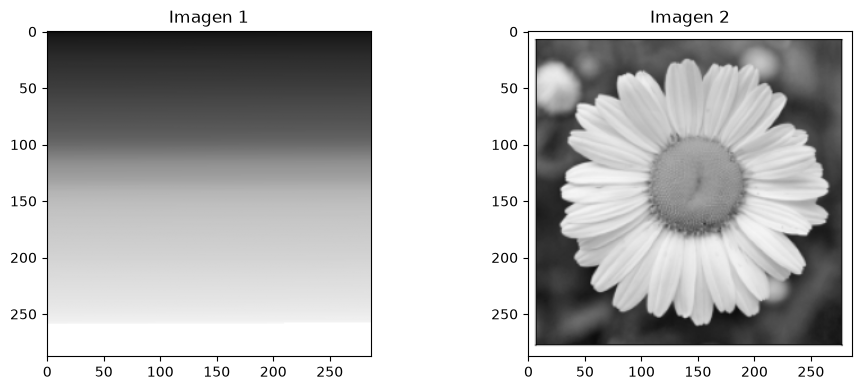

In [12]:
#Leemos las imagenes en escala de grises.
imgen_1 = cv.imread('Material/img1_tp.png', cv.IMREAD_GRAYSCALE)
imgen_2 = cv.imread('Material/img2_tp.png', cv.IMREAD_GRAYSCALE)

#Mostramos ambas imagenes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(imgen_1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Imagen 1")

axes[1].imshow(imgen_2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Imagen 2")

plt.tight_layout()
plt.show()

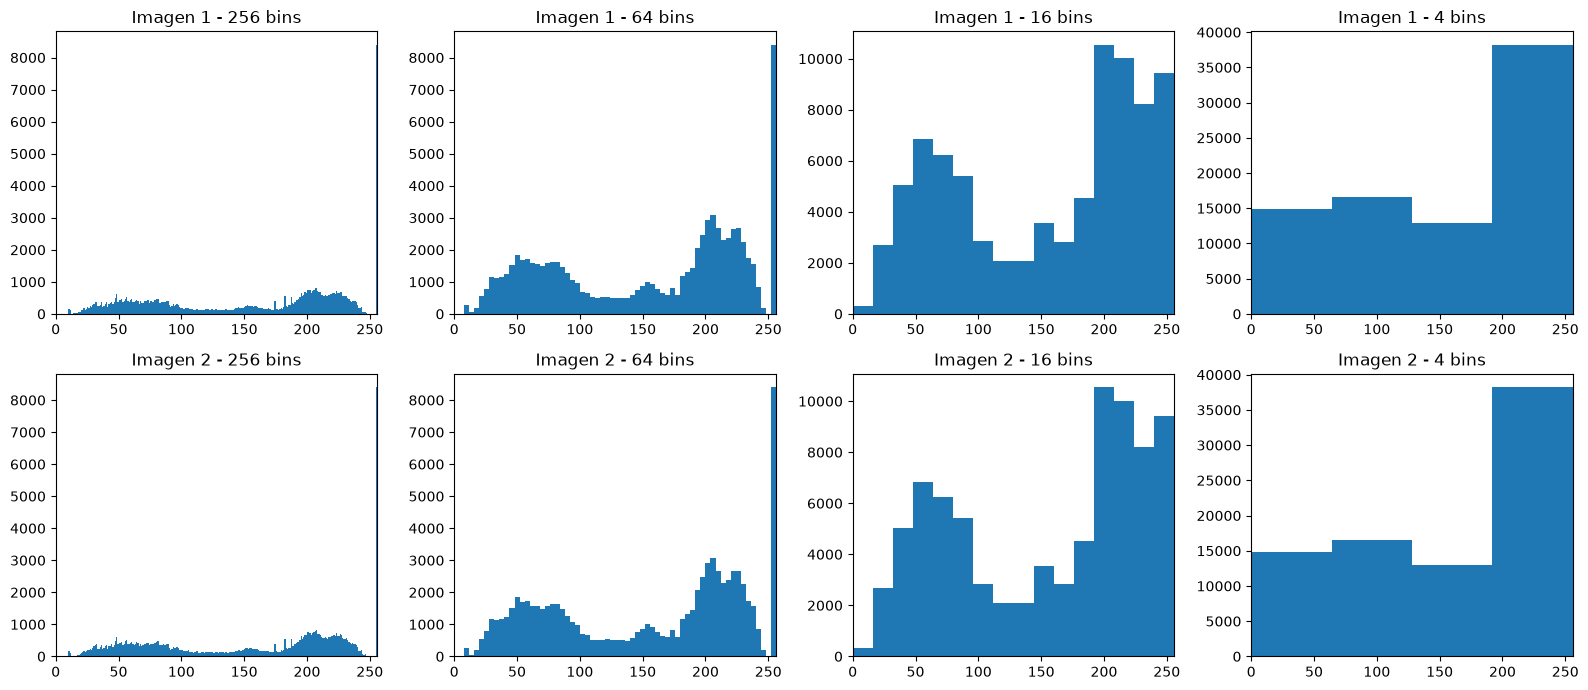

In [13]:
#Creamos una lista con ambas imagenes, otra con los nombres y otra con la cantidad de bins con los que queremos analizar el histograma. 
imagenes = [imgen_1, imgen_2]
nombres = ["Imagen 1", "Imagen 2"]
lista_bins = [256, 64, 16, 4]

#Creamos una grafica con tantas filas como imagenes analicemos y tantas columnas como distinto numeros de bins.
fig, axes = plt.subplots(len(imagenes), len(lista_bins), figsize=(16, 7))

for i, (img, nombre) in enumerate(zip(imagenes, nombres)):
    for j, bins in enumerate(lista_bins):
        axes[i, j].hist(img.ravel(), bins=bins, range=(0, 256))
        axes[i, j].set_title(f"{nombre} - {bins} bins")
        axes[i, j].set_xlim(0, 256)

plt.tight_layout()
plt.show()

#### Comparación de histogramas

Aunque ambas imágenes son visualmente completamente distintas (`img1_tp` es un degradé vertical de oscuro a claro y `img2_tp` es la fotografía de una flor), sus histogramas son **idénticos**. Esto ocurre porque el histograma solo cuenta **cuántos** píxeles hay de cada intensidad, pero descarta **dónde** se encuentran. `img1_tp` contiene exactamente los mismos valores que `img2_tp`, reordenados de menor a mayor a lo largo de la imagen. Toda la información sobre la forma, los bordes y la textura de la flor se pierde al calcular el histograma.

#### Selección de bins y utilidad de los histogramas como features

La elección de la cantidad de bins solo modifica el nivel de detalle. Con **64 bins**, el histograma se suaviza lo suficiente como para distinguir dos grupos de intensidades: uno oscuro, entre aproximadamente 30 y 90, correspondiente al fondo, y otro claro, entre 180 y 240, correspondiente a los pétalos. El valle entre ambos picos permite intuir visualmente que allí se encuentra un umbral adecuado de binarización.

Usados como **única** feature, los histogramas no son confiables: este ejercicio muestra que dos imágenes con contenido totalmente distinto pueden tener exactamente el mismo histograma, por lo que un modelo no podría distinguirlas.

En resumen, el histograma es un descriptor barato e invariante a la posición, pero pierde toda la información espacial. Para clasificación o detección de objetos no alcanza por sí solo, aunque puede utilizarse como feature complementaria.